# Getting started with `dune-bayes`

`dune-bayes` builds on the NAMLSS framework
([Thielmann et al., 2024](https://proceedings.mlr.press/v238/frederik-thielmann24a.html))
and makes it Bayesian: each feature gets its own small neural network (a
*shape function*) that contributes to **every parameter** of a response
distribution — location *and* scale *and* shape — and the network weights
carry a variational posterior, so every feature effect comes with a credible
band. The Bayesian treatment follows the spirit of the
[BAMLSS](https://cran.r-project.org/package=bamlss) R package.

This notebook walks the headline path on tiny **simulated datasets**:

1. simulate data → `DataModule`
2. formula → `BayesianNAMLSS` → `fit`
3. per-feature **effect ribbons** (epistemic uncertainty)
4. the **posterior predictive** (epistemic + aleatoric)
5. `prior_scale` as a smoothing parameter
6. interactions, categorical random effects
7. model comparison with **WAIC / PSIS-LOO**
8. save / load

Everything runs on **CPU in well under a minute** — the networks are tiny and
the datasets have a few hundred rows, so no GPU (or any particular GPU) is
required.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import dune_bayes as db
from dune_bayes.sampling import sample_effects

db.seed_everything(42)
print(f"dune-bayes {db.__version__}, torch {torch.__version__}")

dune-bayes 0.1.0.dev0, torch 2.12.0


## 1. Simulate a small synthetic dataset

A textbook BAMLSS situation: a nonlinear effect, a linear effect, and noise
whose scale **changes with a covariate** (heteroscedasticity):

$$
y_i = \underbrace{\sin(2\pi x_{1i})}_{\text{nonlinear}}
    + \underbrace{0.5\, x_{2i}}_{\text{linear}}
    + \sigma(x_{2i})\,\varepsilon_i,
\qquad
\sigma(x_2) = 0.1 + 0.2\,(x_2 + 1),
\qquad
\varepsilon_i \sim \mathcal{N}(0, 1).
$$

A model of the mean alone would miss half the story — the noise level doubles
across the range of $x_2$. That is exactly what distributional regression is
for.

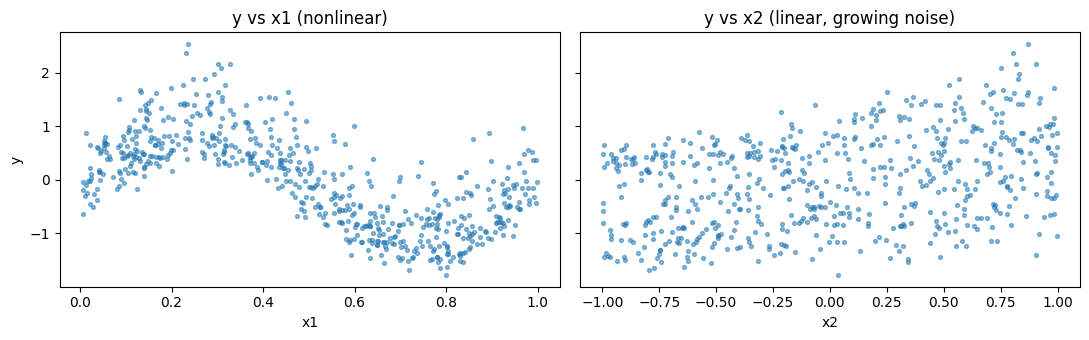

In [2]:
n = 600
rng = np.random.default_rng(42)

x1 = rng.uniform(0.0, 1.0, n)   # nonlinear effect on the mean
x2 = rng.uniform(-1.0, 1.0, n)  # linear effect on the mean, drives the noise scale

mu = np.sin(2 * np.pi * x1) + 0.5 * x2
sigma = 0.10 + 0.20 * (x2 + 1.0)  # heteroscedastic: noise grows with x2
y = mu + sigma * rng.standard_normal(n)

df = pd.DataFrame({"x1": x1, "x2": x2, "y": y})

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
axes[0].scatter(df["x1"], df["y"], s=8, alpha=0.5)
axes[0].set(xlabel="x1", ylabel="y", title="y vs x1 (nonlinear)")
axes[1].scatter(df["x2"], df["y"], s=8, alpha=0.5)
axes[1].set(xlabel="x2", title="y vs x2 (linear, growing noise)")
fig.tight_layout()

## 2. Wrap it in a `DataModule`

`DataModule` owns preprocessing: every column except the response becomes a
feature tensor of shape `(n, 1)`. With `numeric_scaling={}` all numeric
features are standardized (the fitted statistics are reused later via
`dm.transform` for prediction grids, and inverted via `dm.inverse_transform`
for plot axes). Categorical columns would be integer-coded automatically —
see section 8.

In [3]:
dm = db.DataModule(df, response="y", numeric_scaling={})  # {} = standardize all
print("n_obs:", dm.n_obs)
print({name: tuple(t.shape) for name, t in dm.features.items()})

n_obs: 600
{'x1': (600, 1), 'x2': (600, 1)}


## 3. Define the model with a formula and fit it

The mgcv-style formula assigns one shape function per term. `BayesianMLP` is
fully variational: every weight has a Gaussian posterior. Each shape function
outputs `param_count` columns — for `NormalFamily` that is `(loc, scale)`, so
**both** distribution parameters get an additive neural predictor.

`fit` maximizes the ELBO (mean NLL + KL/N) with Adam, with a KL warm-up over
the first 10 epochs to guard against posterior collapse. Passing the
`DataModule` supplies `n_obs` for the KL/N weighting and the training tensors
in one go.

Available shape functions: `BayesianMLP` (fully variational),
`NeuralLinearMLP` (deterministic hidden layers + variational output layer —
cheaper), and the deterministic baselines `MLP` and `ResNet`.

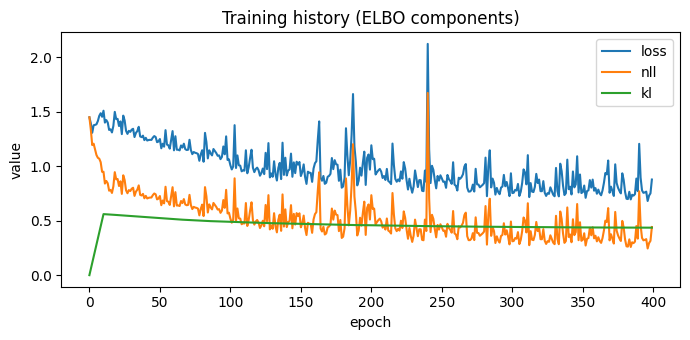

In [4]:
FORMULA = "y ~ BayesianMLP(x1, hidden_dims=(16,)) + BayesianMLP(x2, hidden_dims=(16,))"

model = db.BayesianNAMLSS.from_formula(FORMULA, family=db.NormalFamily(), data=dm)
history = model.fit(dm, epochs=400, lr=1e-2)

fig, ax = plt.subplots(figsize=(7, 3.5))
for key in ("loss", "nll", "kl"):
    ax.plot(history[key], label=key)
ax.set(xlabel="epoch", ylabel="value", title="Training history (ELBO components)")
ax.legend()
fig.tight_layout()

## 4. Effect ribbons — epistemic uncertainty per shape function

`sample_effects` draws `T` posterior weight samples and returns each
feature's **contribution** to the predictor, shape `[T, n, param_count]`.
The spread across draws is *epistemic* uncertainty — what the model does not
know about the shape — cleanly separated from the family's aleatoric noise.

We evaluate on a regular grid (standardized with the fitted `dm.transform`,
never refit) and plot a centered 90% credible ribbon. Centering removes the
arbitrary level — the intercept owns the level; shape functions own the
shape. The dashed line is the (centered) truth used in the simulation.

{'x1': (200, 200, 2), 'x2': (200, 200, 2)}


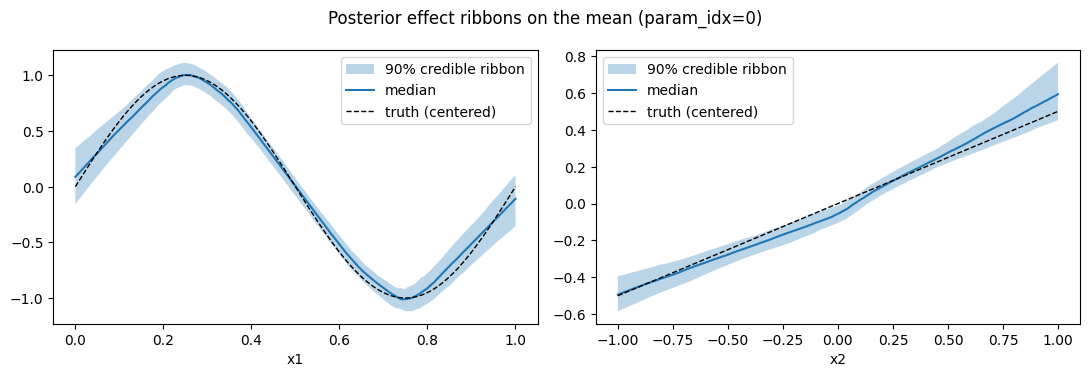

In [5]:
n_grid = 200
grid_df = pd.DataFrame(
    {
        "x1": np.linspace(0.0, 1.0, n_grid),
        "x2": np.linspace(-1.0, 1.0, n_grid),
    }
)
X_grid = dm.transform(grid_df)  # fitted standardization, no refit

effect_draws = sample_effects(model, X_grid, T=200)
print({name: tuple(t.shape) for name, t in effect_draws.items()})

truth = {
    "x1": np.sin(2 * np.pi * grid_df["x1"]),
    "x2": 0.5 * grid_df["x2"],
}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, name in zip(axes, ("x1", "x2"), strict=True):
    db.plot_effect_ribbon(effect_draws[name], grid_df[name], ax=ax, feature_name=name)
    ax.plot(grid_df[name], truth[name] - truth[name].mean(), "k--", lw=1,
            label="truth (centered)")
    ax.legend()
fig.suptitle("Posterior effect ribbons on the mean (param_idx=0)")
fig.tight_layout()

### Every feature contributes to *every* distribution parameter

The same draws hold the contributions to the **scale** predictor
(`param_idx=1`). The model discovers the heteroscedasticity on its own: the
$x_2$ scale-effect rises (we simulated $\sigma$ growing with $x_2$), while
the $x_1$ scale-effect stays essentially flat — as it should.

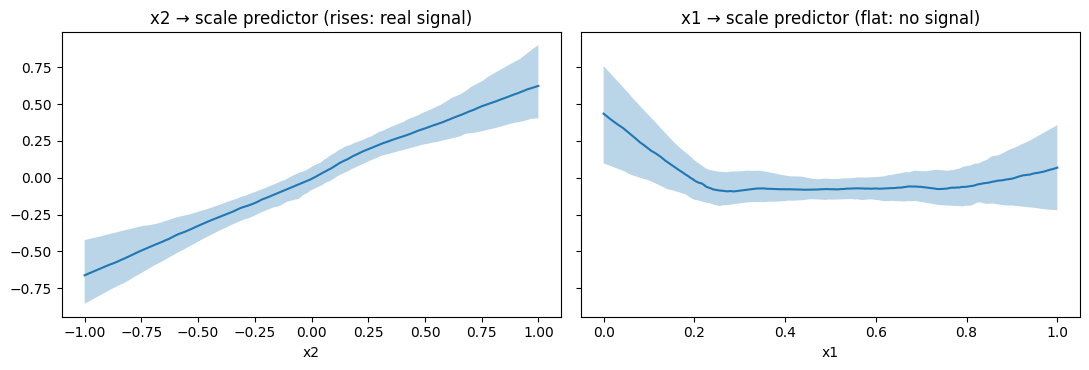

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
db.plot_effect_ribbon(
    effect_draws["x2"], grid_df["x2"], param_idx=1, ax=axes[0], feature_name="x2"
)
axes[0].set_title("x2 → scale predictor (rises: real signal)")
db.plot_effect_ribbon(
    effect_draws["x1"], grid_df["x1"], param_idx=1, ax=axes[1], feature_name="x1"
)
axes[1].set_title("x1 → scale predictor (flat: no signal)")
fig.tight_layout()

## 5. The posterior predictive — epistemic *and* aleatoric

`sample_posterior_predictive` returns a `MixtureSameFamily` over `T` weight
draws: uncertainty **across** mixture components is epistemic, the spread
**within** each component is the family's aleatoric noise. `plot_dist` shows
the band against the observations (sorted by predicted median);
`predictive_quantiles` gives the raw quantiles for custom plots — note how
the band widens with $x_2$-driven noise.

Text(0.5, 1.0, 'Posterior predictive band vs observed y')

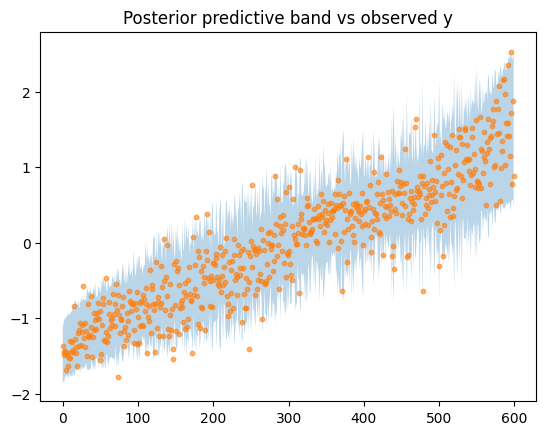

In [7]:
predictive = model.sample_posterior_predictive(dm.features, T=200)
ax = db.plot_dist(predictive, dm.target, seed=0)
ax.set_title("Posterior predictive band vs observed y")

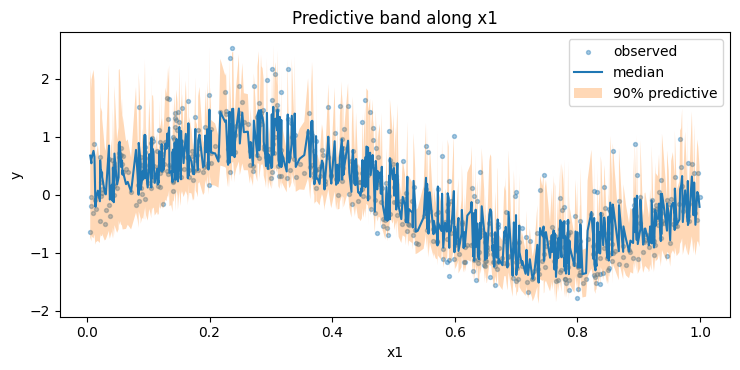

In [8]:
q = db.predictive_quantiles(predictive, credible_interval=0.90, seed=0)

order = np.argsort(df["x1"].to_numpy())
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.scatter(df["x1"], df["y"], s=8, alpha=0.4, label="observed")
ax.plot(df["x1"].to_numpy()[order], q["mid"].numpy()[order], lw=1.5, label="median")
ax.fill_between(
    df["x1"].to_numpy()[order],
    q["lo"].numpy()[order],
    q["hi"].numpy()[order],
    alpha=0.3,
    label="90% predictive",
)
ax.set(xlabel="x1", ylabel="y", title="Predictive band along x1")
ax.legend()
fig.tight_layout()

## 6. `prior_scale` as a smoothing parameter

The per-feature `prior_scale` is the direct analog of an mgcv smoothing
parameter: a tight prior shrinks the shape function toward flat, a loose one
lets it wiggle. Refitting the same formula with two values makes this
visible.

Beyond fixed values, the prior tiers of ADR-0002 are reachable from the
formula too: `BayesianMLP(x1, prior='empirical_bayes')` learns the scale as
a point estimate, and `prior={'mode': 'hierarchical', 'tau': 1.0}` puts a
hyperprior on it.

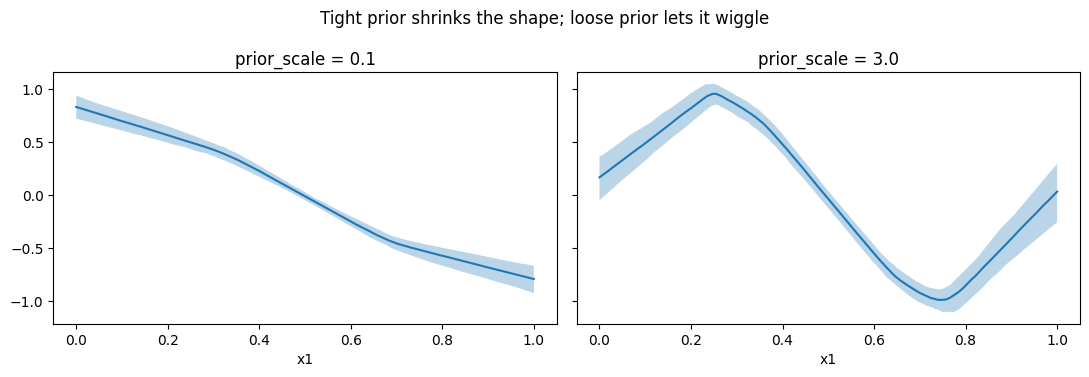

In [9]:
models_ps = {}
for ps in (0.1, 3.0):
    formula_ps = (
        f"y ~ BayesianMLP(x1, hidden_dims=(16,), prior_scale={ps})"
        f" + BayesianMLP(x2, hidden_dims=(16,), prior_scale={ps})"
    )
    m = db.BayesianNAMLSS.from_formula(formula_ps, family=db.NormalFamily(), data=dm)
    m.fit(dm, epochs=400, lr=1e-2)
    models_ps[ps] = m

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (ps, m) in zip(axes, models_ps.items(), strict=True):
    draws_ps = sample_effects(m, X_grid, T=200)
    db.plot_effect_ribbon(draws_ps["x1"], grid_df["x1"], ax=ax, feature_name="x1")
    ax.set_title(f"prior_scale = {ps}")
fig.suptitle("Tight prior shrinks the shape; loose prior lets it wiggle")
fig.tight_layout()

## 7. Interactions — a joint net over two inputs

`BayesianMLP(x1):BayesianMLP(x2)` builds one network over the concatenated
inputs (architecture kwargs come from the first factor). We simulate a pure
interaction, $y = \sin(2\pi x_1)\cdot x_2 + \varepsilon$, and plot the
posterior-mean surface next to its epistemic standard deviation.

For interactions, `sample_effects` expects the **pre-concatenated** grid
under the joint key `"x1:x2"`.

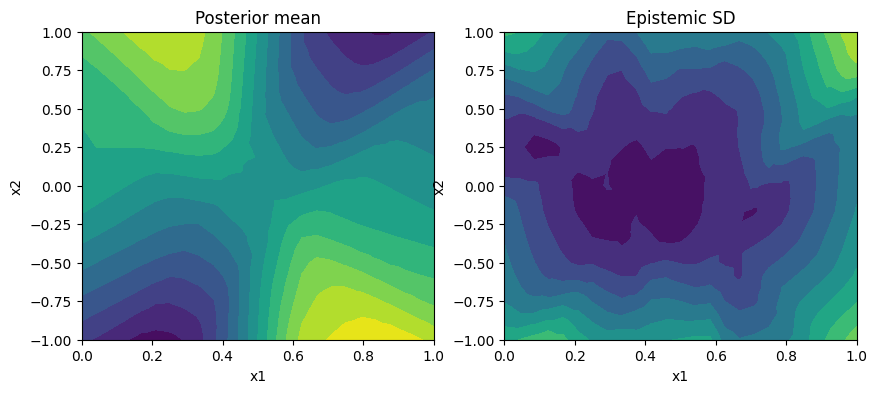

In [10]:
y_int = np.sin(2 * np.pi * x1) * x2 + 0.1 * rng.standard_normal(n)
df_int = pd.DataFrame({"x1": x1, "x2": x2, "y": y_int})
dm_int = db.DataModule(df_int, response="y", numeric_scaling={})

model_int = db.BayesianNAMLSS.from_formula(
    "y ~ BayesianMLP(x1, hidden_dims=(16, 16)):BayesianMLP(x2)",
    family=db.NormalFamily(),
    data=dm_int,
)
history_int = model_int.fit(dm_int, epochs=500, lr=1e-2)

g1, g2 = np.meshgrid(np.linspace(0, 1, 25), np.linspace(-1, 1, 25))
grid_df_int = pd.DataFrame({"x1": g1.ravel(), "x2": g2.ravel()})
Xg_int = dm_int.transform(grid_df_int)
grid_joint = torch.cat([Xg_int["x1"], Xg_int["x2"]], dim=-1)  # (625, 2)

draws_int = sample_effects(model_int, {"x1:x2": grid_joint}, T=100)
fig = db.plot_interaction_surface(
    draws_int["x1:x2"], g1.ravel(), g2.ravel(), feature_names=("x1", "x2")
)

## 8. Categorical features — Bayesian embeddings as random effects

A `BayesianEmbedding` is the neural analog of a random effect: one
posterior row per level, all sharing a common prior, which **partially
pools** rare levels toward zero. We simulate 8 groups with deliberately
imbalanced sizes (150 observations down to 5) and a true effect per group.

`DataModule` integer-codes the categorical column automatically and exposes
the level count via `dm.num_levels`. For embedding terms we build the
formula as a plain dict (the embedding wants `(n,)` long indices, so the
`(n, 1)` column is squeezed), with `embedding_dim` equal to the family's
`param_count` — the per-level effect, like every other term, contributes to
every distribution parameter.

In the plot, watch the rare groups (right side): their intervals are wider
*and* their estimates are pulled toward zero — that is partial pooling
doing its job.

In [11]:
from dune_bayes.layers import BayesianEmbedding
from dune_bayes.shapes import BayesianMLP

groups = list("ABCDEFGH")
sizes = [150, 120, 90, 60, 30, 20, 10, 5]  # deliberately imbalanced
true_group_effects = rng.normal(0.0, 0.6, len(groups))

g_col = np.repeat(groups, sizes)
n_cat = len(g_col)
x_cat = rng.uniform(-1.0, 1.0, n_cat)
y_cat = (
    true_group_effects[np.searchsorted(groups, g_col)]
    + 0.5 * x_cat
    + 0.3 * rng.standard_normal(n_cat)
)
df_cat = pd.DataFrame({"x": x_cat, "group": g_col, "y": y_cat})

dm_cat = db.DataModule(df_cat, response="y", numeric_scaling={})
K = dm_cat.num_levels["group"]
print("levels:", K, "| counts:", df_cat["group"].value_counts().sort_index().to_dict())

family = db.NormalFamily()
formula_cat = {
    "x": BayesianMLP(1, family.param_count, hidden_dims=[16], kl_divisor=dm_cat.n_obs),
    "group": BayesianEmbedding(
        num_embeddings=K, embedding_dim=family.param_count, kl_divisor=dm_cat.n_obs
    ),
}
model_cat = db.BayesianNAMLSS(formula=formula_cat, family=family, n_obs=dm_cat.n_obs)

X_cat = {
    "x": dm_cat.features["x"],
    "group": dm_cat.features["group"].squeeze(-1),  # BayesianEmbedding wants (n,)
}
history_cat = model_cat.fit(X_cat, dm_cat.target, epochs=400, lr=1e-2)

levels: 8 | counts: {'A': 150, 'B': 120, 'C': 90, 'D': 60, 'E': 30, 'F': 20, 'G': 10, 'H': 5}


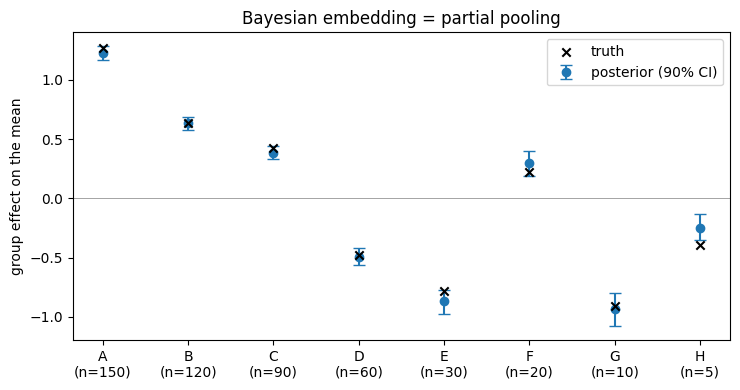

In [12]:
# Per-level posterior effects: feed every level index once.
level_draws = sample_effects(
    model_cat,
    {"x": dm_cat.features["x"][:1], "group": torch.arange(K)},
    T=400,
)["group"][..., 0]  # (T, K) — contribution to the mean
# Center each draw across levels: the intercept owns the overall level, so
# group effects are only identified up to a constant.
level_draws = level_draws - level_draws.mean(dim=1, keepdim=True)

lo, mid, hi = level_draws.quantile(torch.tensor([0.05, 0.50, 0.95]), dim=0)
truth_centered = true_group_effects - true_group_effects.mean()

fig, ax = plt.subplots(figsize=(7.5, 4))
xs = np.arange(K)
ax.errorbar(
    xs,
    mid,
    yerr=[(mid - lo).numpy(), (hi - mid).numpy()],
    fmt="o",
    capsize=4,
    label="posterior (90% CI)",
)
ax.scatter(xs, truth_centered, marker="x", color="k", zorder=3, label="truth")
ax.axhline(0.0, lw=0.5, color="gray")
ax.set_xticks(xs, [f"{g}\n(n={s})" for g, s in zip(groups, sizes, strict=True)])
ax.set(ylabel="group effect on the mean", title="Bayesian embedding = partial pooling")
ax.legend()
fig.tight_layout()

## 9. Model comparison with WAIC and PSIS-LOO

`waic` and `loo` (via [arviz](https://python.arviz.org)) estimate
out-of-sample predictive accuracy from the pointwise log-likelihood over `T`
posterior draws; `compare` ranks models by LOO ELPD. Two things to know:

- **PSIS-LOO needs a weight posterior** — `loo`/`compare` raise for the
  deterministic baselines (`MLP`, `ResNet`), whose importance weights are all
  identical. Use `waic` for those.
- **Pareto-k warnings are expected here**: reliable PSIS-LOO wants roughly
  `T ≥ 4·n` draws, and we keep `T` modest so the notebook stays fast. For a
  real comparison, raise `T`.

The deterministic MLP posts the best in-sample WAIC on this easy, noise-dominated
dataset — at `p ≈ 3` effective parameters it is essentially a point fit, while
the Bayesian models pay an uncertainty premium in exchange for the calibrated
bands above. This is exactly the trade-off the comparison tooling is for.

In [13]:
model_nl = db.BayesianNAMLSS.from_formula(
    "y ~ NeuralLinearMLP(x1, hidden_dims=(16,)) + NeuralLinearMLP(x2, hidden_dims=(16,))",
    family=db.NormalFamily(),
    data=dm,
)
model_nl.fit(dm, epochs=400, lr=1e-2)

model_det = db.BayesianNAMLSS.from_formula(
    "y ~ MLP(x1, hidden_dims=(16,)) + MLP(x2, hidden_dims=(16,))",
    family=db.NormalFamily(),
    data=dm,
)
model_det.fit(dm, epochs=400, lr=1e-2)

X, y_t = dm.features, dm.target
for name, m, T in [
    ("BayesianMLP", model, 500),
    ("NeuralLinearMLP", model_nl, 500),
    ("deterministic MLP", model_det, 10),
]:
    w = db.waic(m, X, y_t, T=T)
    print(f"{name:>18}: WAIC elpd = {w.elpd:8.2f}  (p = {w.p:6.2f}, se = {w.se:.2f})")

       BayesianMLP: WAIC elpd =  -241.51  (p =  69.75, se = 15.71)
   NeuralLinearMLP: WAIC elpd =  -286.99  (p =  39.87, se = 16.69)
 deterministic MLP: WAIC elpd =  -154.50  (p =   3.17, se = 16.39)


In [14]:
comp = db.compare({"BayesianMLP": model, "NeuralLinearMLP": model_nl}, X, y_t, T=500)
comp

/Users/entropy/Git/dune-bayes/.venv-torch/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.63 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/entropy/Git/dune-bayes/.venv-torch/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.63 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd,p,elpd_diff,weight,se,dse,warning
BayesianMLP,0,-250.0,79.5,0.0,0.89,16.0,0.0,True
NeuralLinearMLP,1,-290.0,39.0,-40.0,0.11,17.0,10.0,True


## 10. Save / load round-trip

`save` writes the variational parameters plus the model config; `load` needs
the architecture rebuilt by the caller (a fresh formula dict) and restores
the weights **exactly** — `max|Δw| == 0`, not approximately.

In [15]:
import tempfile
from pathlib import Path

path = Path(tempfile.mkdtemp()) / "model.pt"
model.save(path)

fresh_formula = {
    "x1": BayesianMLP(1, 2, hidden_dims=[16], kl_divisor=dm.n_obs),
    "x2": BayesianMLP(1, 2, hidden_dims=[16], kl_divisor=dm.n_obs),
}
loaded = db.BayesianNAMLSS.load(path, formula=fresh_formula, family=db.NormalFamily())

max_delta = max(
    (model.state_dict()[k] - loaded.state_dict()[k]).abs().max().item()
    for k in model.state_dict()
)
print(f"max |Δw| after round-trip: {max_delta}")

max |Δw| after round-trip: 0.0


## Where to go next

- [`CONTEXT.md`](../CONTEXT.md) — the statistical contract and glossary
  (epistemic vs aleatoric, shape function, `prior_scale`-as-smoothness).
- [`docs/adr/`](../docs/adr/) — the six design decisions behind what you just
  ran (inference engine, priors, predictive/comparison architecture, the
  `VariationalDense` atom, categoricals & interactions, the PyTorch backend).
- Other families: swap `db.NormalFamily()` for `db.StudentTFamily()`
  (robust, 3 parameters) or `db.GammaFamily()` (positive responses) — every
  shape function automatically grows the matching number of output columns.
- Minibatching for larger data: `model.fit(dm, batch_size=64, seed=0)` —
  the KL is still weighted by the full-data `n_obs`, so the ELBO stays
  unbiased.

A note on reproducibility: `seed_everything` makes results reproducible
**within one model object**; two freshly built models will not match draw for
draw even under the same global seed (reparameterization noise is consumed
during construction and training).